In [4]:
import pandas as pd

df = pd.read_csv(
    "../data/predictive_maintenance.csv"
)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df = df.drop(
    ["UDI", "Product ID"],
    axis=1
)

df = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True
)

df.columns = (
    df.columns
      .str.replace('[', '', regex=False)
      .str.replace(']', '', regex=False)
      .str.replace(' ', '_')
)

In [6]:
X = df.drop(
    "Machine_failure",
    axis=1
)

print(X.shape)

(10000, 12)


In [7]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.03,
    random_state=42
)

iso_model.fit(X)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [8]:
df["Anomaly"] = iso_model.predict(X)

In [9]:
df["Anomaly"].value_counts()

Anomaly
 1    9700
-1     300
Name: count, dtype: int64

In [10]:
df["Anomaly"] = df["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

In [11]:
df["Anomaly"].value_counts()

Anomaly
Normal     9700
Anomaly     300
Name: count, dtype: int64

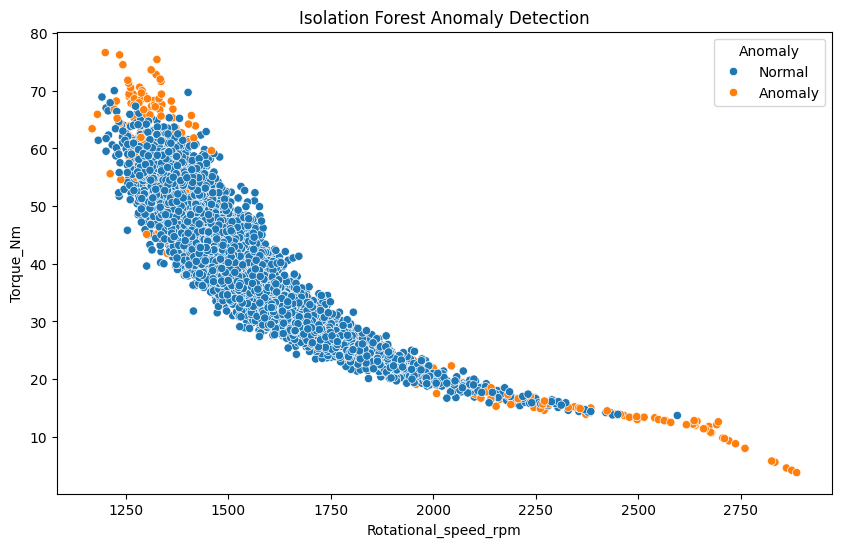

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Rotational_speed_rpm",
    y="Torque_Nm",
    hue="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.show()

In [13]:
import joblib

joblib.dump(
    iso_model,
    "../models/isolation_forest.pkl"
)

print("Isolation Forest Saved")

Isolation Forest Saved
